In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from windfield import WindField
from tracer import solver, initial_velocity, fetch_wind_data

Final position: [ 1.41734705e+02  0.00000000e+00 -5.59856555e-02], Total time: 2.61 s
Final position: [ 1.57179432e+02  0.00000000e+00 -1.84935542e-02], Total time: 3.02 s
Final position: [ 2.05280323e+02  3.38259314e+00 -2.72708789e-02], Total time: 4.33 s
Final position: [140.41743301   1.31365222  -0.14828636], Total time: 2.60 s
Final position: [149.53898487   3.09632094  -0.15907356], Total time: 2.86 s
Final position: [ 1.53021415e+02  2.24466053e+00 -1.44639901e-01], Total time: 3.00 s
Final position: [ 2.04377866e+02  9.23021814e+00 -2.74992102e-02], Total time: 4.57 s
Final position: [ 1.33112423e+02  1.30706605e+00 -8.69376651e-02], Total time: 2.52 s
Final position: [139.73932554   4.16825284  -0.1542416 ], Total time: 2.73 s
Final position: [ 1.31866064e+02  2.10170194e-16 -1.46622002e-01], Total time: 2.51 s
Final position: [ 1.81873570e+02  7.98365464e+00 -5.74966217e-02], Total time: 4.13 s
Final position: [ 1.33066464e+02 -1.24075897e+00 -8.70648095e-02], Total time: 2.

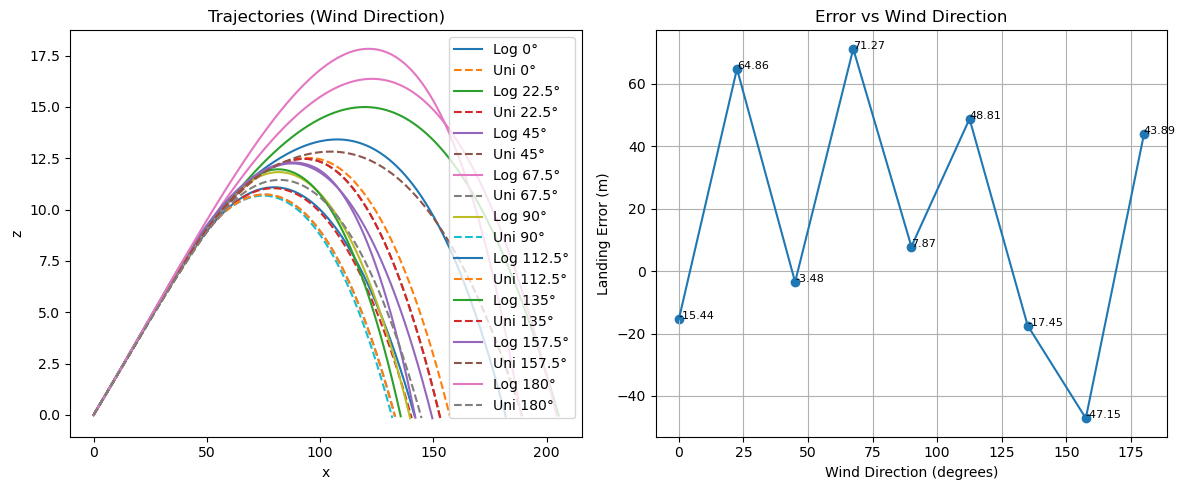

Final position: [ 2.00678518e+02  1.69074598e+01 -9.66314354e-02], Total time: 4.67 s
Final position: [ 1.31866064e+02  3.73562689e-16 -1.46622002e-01], Total time: 2.51 s
Final position: [ 1.73877776e+02  9.36743975e+00 -5.69192132e-02], Total time: 3.70 s
Final position: [ 1.31866064e+02  2.84042543e-16 -1.46622002e-01], Total time: 2.51 s
Final position: [ 1.49310551e+02  5.95538744e+00 -9.49248477e-02], Total time: 3.00 s
Final position: [ 1.31866064e+02  2.55464689e-16 -1.46622002e-01], Total time: 2.51 s
Final position: [ 1.36158216e+02  3.51710382e+00 -9.74095983e-02], Total time: 2.63 s
Final position: [ 1.31866064e+02  1.84247902e-16 -1.46622002e-01], Total time: 2.51 s
Final position: [ 1.32171276e+02  2.76292135e+00 -1.06641456e-01], Total time: 2.52 s
Final position: [ 1.31866064e+02  1.55906549e-16 -1.46622002e-01], Total time: 2.51 s
Final position: [131.84329052   1.64220538  -0.15343158], Total time: 2.51 s
Final position: [ 1.31866064e+02  9.01000339e-17 -1.46622002e-0

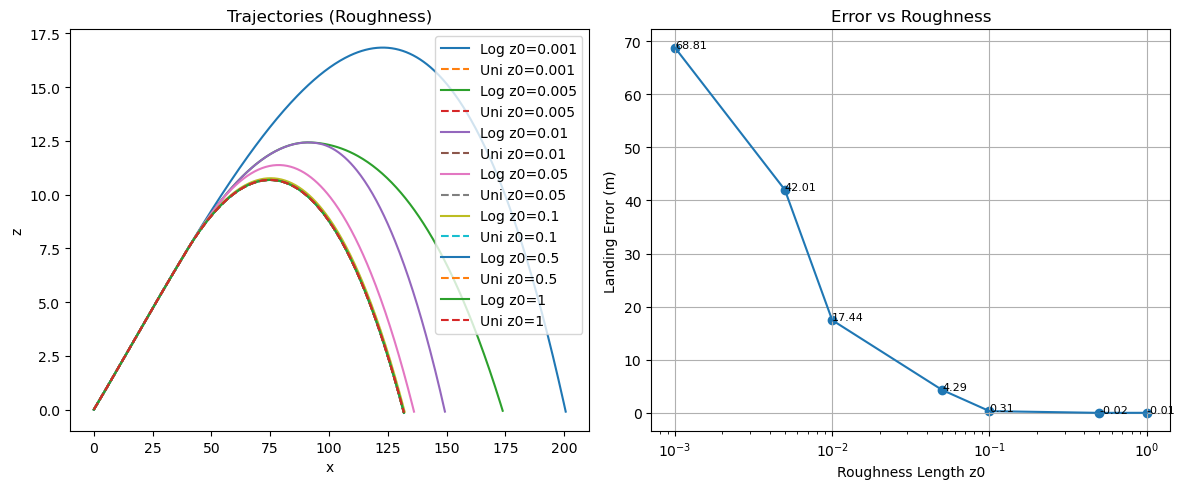

In [2]:
# Input
shot_speed = 76.44384
shot_angle = 10.4
shot_spin = 2545
P0 = [0, 0, 0]

# Simulation
def run_simulation(direction=90, z0=0.03):
    # Log wind
    log_wind = WindField(nx=300, ny=500, nz=100,
                         direction=direction, profile='log', z0=z0)

    log_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    log_W0 = np.array([0, -shot_spin, 0])
    log_t, log_p, log_v, log_w = solver(P0, log_V0, log_W0, log_wind, dt=0.01)

    upper_bound = max(log_p[:, 2])

    # Compute equivalent uniform wind
    wind_collect = []
    for i in range(max(1, round(upper_bound))):
        wind_collect.append(log_wind.get_point(0, 0, i)['velocity'][0])

    U_ref_uni = sum(wind_collect) / len(wind_collect)

    # Uniform wind
    uni_wind = WindField(nx=300, ny=500, nz=100,
                         direction=direction, profile='uniform', U_ref=U_ref_uni)

    uni_V0 = initial_velocity(speed=shot_speed, angle=shot_angle)
    uni_W0 = np.array([0, -shot_spin, 0])
    uni_t, uni_p, uni_v, uni_w = solver(P0, uni_V0, uni_W0, uni_wind, dt=0.01)

    return log_p, uni_p


# Wind

directions = [0, 22.5, 45,67.5, 90, 112.5, 135, 157.5, 180]

dir_results = {}
dir_errors = []

for d in directions:
    log_p, uni_p = run_simulation(direction=d, z0=0.03)
    dir_results[d] = (log_p, uni_p)

    error = (log_p[-1, 0] - uni_p[-1, 0]) 
    dir_errors.append(error)

# Plot left

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for d in directions:
    log_p, uni_p = dir_results[d]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log {d}°')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni {d}°')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Wind Direction)")
ax1.legend()

# Plot right

ax2.scatter(directions, dir_errors)
ax2.plot(directions, dir_errors)

for x, y in zip(directions, dir_errors):
    ax2.text(x, y, f"{y:.2f}", fontsize=8)

ax2.set_xlabel("Wind Direction (degrees)")
ax2.set_ylabel("Landing Error (m)")
ax2.set_title("Error vs Wind Direction")
ax2.grid()

plt.tight_layout()
plt.show()


# Roughness

roughness_values = [0.001, 0.005, 0.01, 0.05, 0.1, 0.5, 1]

rough_results = {}
rough_errors = []

for z in roughness_values:
    log_p, uni_p = run_simulation(direction=90, z0=z)
    rough_results[z] = (log_p, uni_p)

    error = (log_p[-1, 0] - uni_p[-1, 0])
    rough_errors.append(error)

# Plot left
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for z in roughness_values:
    log_p, uni_p = rough_results[z]

    ax1.plot(log_p[:, 0], log_p[:, 2], label=f'Log z0={z}')
    ax1.plot(uni_p[:, 0], uni_p[:, 2], '--', label=f'Uni z0={z}')

ax1.set_xlabel("x")
ax1.set_ylabel("z")
ax1.set_title("Trajectories (Roughness)")
ax1.legend()

# Plot right

ax2.scatter(roughness_values, rough_errors)
ax2.plot(roughness_values, rough_errors)

for x, y in zip(roughness_values, rough_errors):
    ax2.text(x, y, f"{y:.2f}", fontsize=8)

ax2.set_xscale("log")
ax2.set_xlabel("Roughness Length z0")
ax2.set_ylabel("Landing Error (m)")
ax2.set_title("Error vs Roughness")
ax2.grid()

plt.tight_layout()
plt.show()